# On-the-ball Shape: Inter Milan 2015/16

![Pass networks for Inter's two most-used formations](../output/Inter_Milan_2015-2016_pass_networks.png)

Roberto Mancini's Inter used **twelve different formations** in Serie A 2015/16, and no single starting XI played together more than a couple of times. A classic player-based pass network would blur these systems together. This notebook builds **one pass network per formation**, with **positions as nodes**, so the shapes can be compared side by side.

- **Data:** StatsBomb open data, all 38 Serie A matches of Inter's season
- **Nodes:** formation positions, placed at their average on-ball location and labelled with the player who spent the most minutes there
- **Size and width:** completed passes per 90 minutes in that formation
- **Colour:** expected threat (xT) added by passes

The reusable code lives in the [`statsbomb_tools`](../statsbomb_tools) package; this notebook only sets the parameters and shows the results.

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path

from statsbomb_tools.data import load_competitions, load_matches, get_team_id, team_matches, load_events
from statsbomb_tools.lineups import (
    formation_at_each_event, event_durations,
    minutes_by_formation, minutes_by_position, main_player_by_position,
)
from statsbomb_tools.passes import open_play_passes, receiver_positions, load_xT_grid, pass_xT
from statsbomb_tools.network import build_nodes, build_edges
from statsbomb_tools.plotting import use_space_mono, plot_formations

In [2]:
# Analysis parameters
COMPETITION_ID = 12      # Serie A
SEASON_ID = 27           # 2015/16
TEAM_NAME = "Inter Milan"
MIN_MINUTES = 700        # only plot formations used for at least this long
MIN_EDGE_P90 = 4         # hide links with fewer completed passes per 90

# Paths, relative to this notebook
DATA_DIR = Path("../data")
OUTPUT_DIR = Path("../output")

# Short names for labels; anyone not listed keeps their StatsBomb name
DISPLAY_NAMES = {
    "Samir Handanovič": "Handanovič",
    "Danilo D''Ambrosio": "D'Ambrosio",
    "João Miranda de Souza Filho": "Miranda",
    "Jeison Fabián Murillo Cerón": "Murillo",
    "Yuto Nagatomo": "Nagatomo",
    "Alex Nicolao Telles": "Alex Telles",
    "Gary Alexis Medel Soto": "Medel",
    "Geoffrey Kondogbia": "Kondogbia",
    "Felipe Melo de Carvalho": "Felipe Melo",
    "Jonathan Ludovic Biabiany": "Biabiany",
    "Stevan Jovetić": "Jovetić",
    "Ivan Perišić": "Perišić",
    "Mauro Emanuel Icardi Rivero": "Icardi",
}

## 1. Data

All of Inter's league matches, and every event in them (both teams), cached locally after the first download.

In [3]:
comps = load_competitions()
season = comps[(comps["competition_id"] == COMPETITION_ID) & (comps["season_id"] == SEASON_ID)].iloc[0]

matches = load_matches(COMPETITION_ID, SEASON_ID)
TEAM_ID = get_team_id(matches, TEAM_NAME)
team_all_matches = team_matches(matches, TEAM_ID)

events = load_events(team_all_matches["match_id"], DATA_DIR / "events")
print(f"{season['competition_name']} {season['season_name']}: {len(team_all_matches)} {TEAM_NAME} matches, {len(events):,} events")

38/38 matches loaded
Serie A 2015/2016: 38 Inter Milan matches, 138,481 events


## 2. Formations

Each event is tagged with the formation Inter were using at that moment (from StatsBomb's Starting XI and Tactical Shift events), and timed using the gap to the next event. Summing gives the minutes spent in each formation, including changes during matches.

In [4]:
events["formation"] = formation_at_each_event(events, TEAM_ID)
events["duration"] = event_durations(events)
formation_minutes = minutes_by_formation(events)

formations = formation_minutes[formation_minutes["minutes"] >= MIN_MINUTES].index.tolist()
print(f"Formations used for at least {MIN_MINUTES} minutes: {formations}")
formation_minutes

Formations used for at least 700 minutes: ['4-2-3-1', '4-4-2']


,minutes,matches
formation,,
4-2-3-1,977.0,17
4-4-2,770.0,13
4-3-3,546.0,13
4-1-2-1-2,467.0,9
3-5-2,296.0,10
4-4-1-1,249.0,9
4-1-4-1,142.0,3
3-4-1-2,73.0,4
4-3-2-1,65.0,1


## 3. Who played where

Lineups are rebuilt through every substitution, tactical shift and red card, giving the minutes each player spent in each position. The player with the most minutes labels the node; their share shows how settled the position was.

In [5]:
position_minutes = minutes_by_position(events, TEAM_ID)
top_players = main_player_by_position(position_minutes, formation_minutes)

(
    top_players[top_players["formation"].isin(formations)]
    .assign(player=lambda d: d["player"].map(lambda p: DISPLAY_NAMES.get(p, p))
                             + " (" + d["share"].map("{:.0%}".format) + ")")
    .pivot(index="position", columns="formation", values="player")
    .fillna("")
)

formation,4-2-3-1,4-4-2
position,,
Center Attacking Midfield,Jovetić (37%),
Center Forward,Icardi (80%),
Goalkeeper,Handanovič (90%),Handanovič (100%)
Left Back,Nagatomo (51%),Alex Telles (46%)
Left Center Back,Murillo (67%),Murillo (71%)
Left Center Forward,,Jovetić (45%)
Left Defensive Midfield,Kondogbia (53%),Felipe Melo (42%)
Left Midfield,,Perišić (63%)
Left Wing,Perišić (81%),


## 4. Passes and expected threat

- **Open play only:** set pieces and injury clearances are excluded.
- **Receiver position** comes from the Ball Receipt event linked to each pass, i.e. where the receiver was playing at that moment.
- **xT** uses Karun Singh's open 12 × 8 grid: the value of the end zone minus the start zone. Incomplete passes score 0, and backward passes count as 0 rather than negative, so recycling possession is not penalised.

In [6]:
open_play = open_play_passes(events, TEAM_ID)
open_play["formation"] = events["formation"]

network_passes = open_play[open_play["formation"].isin(formations)].copy()
network_passes["receiver_position"] = receiver_positions(network_passes, events, TEAM_ID)
network_passes["xT"] = pass_xT(network_passes, load_xT_grid(DATA_DIR / "xT_grid.json"))

network_passes.groupby("formation").agg(
    passes=("completed", "size"),
    completed=("completed", "sum"),
    mean=("completed","mean"),
    xT=("xT", "sum"),
).round(3)

,passes,completed,mean,xT
formation,,,,
4-2-3-1,5294,4271,0.807,14.762
4-4-2,4179,3397,0.813,13.911


## 5. Network tables

**Nodes:** one per position, placed at the average of where it passed from and where it received. 

**Edges:** completed passes between two positions, both directions combined. Everything is per 90 minutes of the formation, so the two shapes are directly comparable.

In [7]:
nodes = build_nodes(network_passes, formation_minutes, top_players)
edges = build_edges(network_passes, nodes, formation_minutes)

(
    nodes.assign(player=nodes["player"].map(lambda p: DISPLAY_NAMES.get(p, p)))
    .sort_values(["formation", "xT_p90"], ascending=[True, False])
    [["formation", "position", "player", "completed_p90", "completion", "xT_p90"]]
    .round(2)
    .reset_index(drop=True)
)

,formation,position,player,completed_p90,completion,xT_p90
0,4-2-3-1,Left Back,Nagatomo,39.33,0.77,0.21
1,4-2-3-1,Right Wing,Biabiany,31.78,0.77,0.19
2,4-2-3-1,Center Attacking Midfield,Jovetić,35.56,0.76,0.18
3,4-2-3-1,Right Back,D'Ambrosio,35.93,0.76,0.17
4,4-2-3-1,Left Wing,Perišić,33.72,0.73,0.15
5,4-2-3-1,Left Defensive Midfield,Kondogbia,56.38,0.87,0.12
6,4-2-3-1,Right Defensive Midfield,Medel,53.43,0.88,0.11
7,4-2-3-1,Center Forward,Icardi,14.00,0.72,0.08
8,4-2-3-1,Right Center Back,Miranda,40.90,0.82,0.08
9,4-2-3-1,Left Center Back,Murillo,40.53,0.88,0.06


## 6. The figure

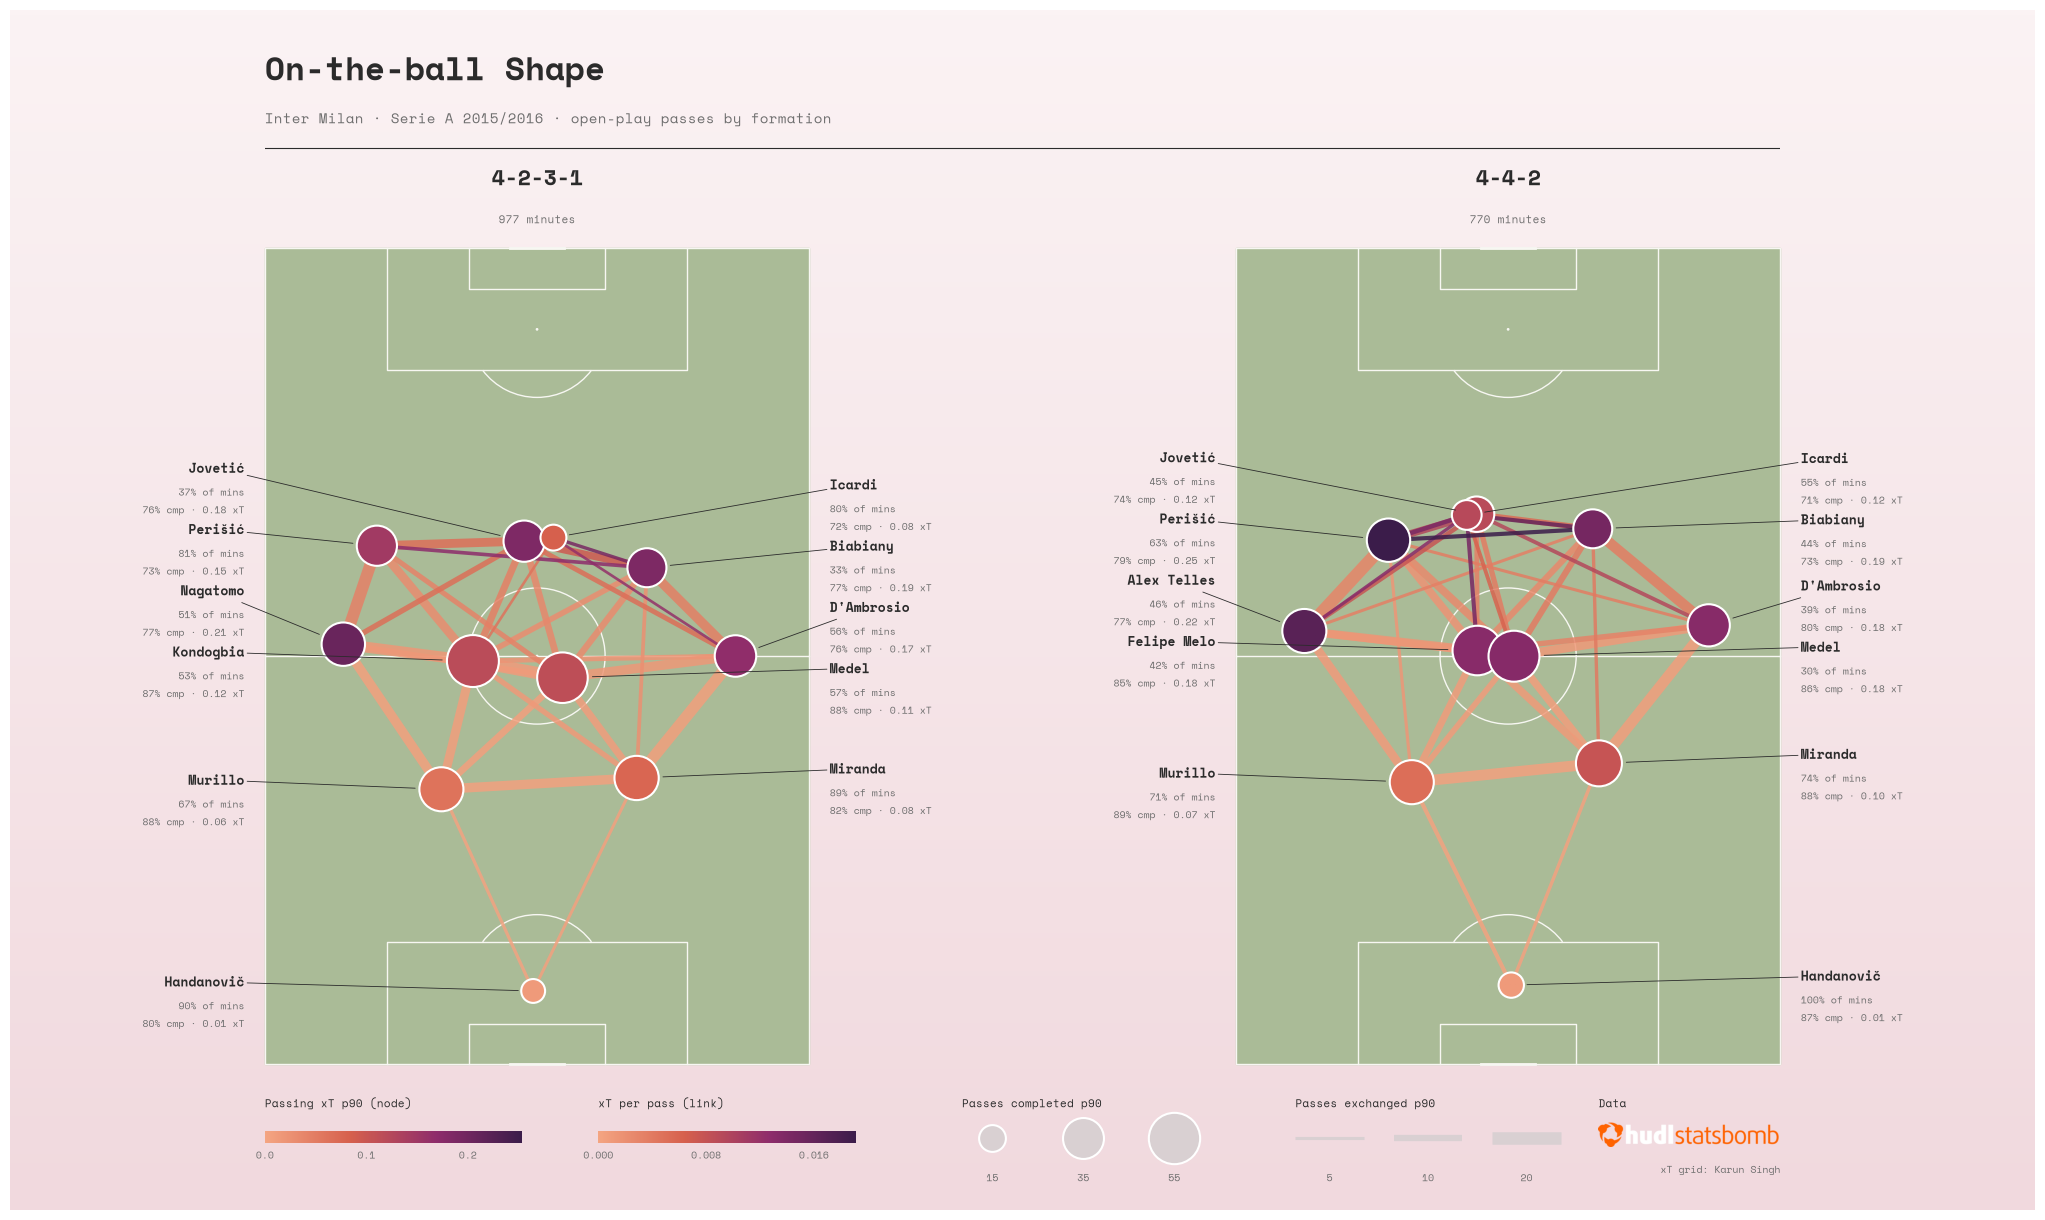

In [8]:
use_space_mono(DATA_DIR / "fonts")

fig = plot_formations(
    nodes, edges, formation_minutes, formations,
    title="On-the-ball Shape",
    subtitle=f"{TEAM_NAME} · {season['competition_name']} {season['season_name']} · open-play passes by formation",
    display_names=DISPLAY_NAMES,
    min_edge_p90=MIN_EDGE_P90,
    logo=Path("../assets/statsbomb-logo.png"),
)

OUTPUT_DIR.mkdir(exist_ok=True)
filename = f"{TEAM_NAME}_{season['season_name']}_pass_networks.png".replace(" ", "_").replace("/", "-")
fig.savefig(OUTPUT_DIR / filename, dpi=200)

## Notes and limitations

- **Averages over many matches.** A node is where a position was on the ball across every match in that formation, not a snapshot of one game. Different players in the same position are merged.
- **Position labels come from StatsBomb.** The same tactical role can be coded differently between matches (e.g. a wide midfielder in 4-4-2 vs a winger in 4-2-3-1).
- **xT is a simple, static model.** It values ball movement between zones; it ignores pressure, defensive shape and pass difficulty, and incomplete passes are not penalised.
- **Minutes are timed from event gaps,** so they include stoppage time and are approximate to a few seconds.